## Imports

In [76]:
import mesmer
import model
import model_analysis
import Play

import importlib
import matplotlib.pyplot as plt
import xarray as xr
import xskillscore as xs
import numpy as np

import cartopy.crs as ccrs

from PIL import Image



### Updates (temp)

In [77]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);



## Load Data

In [78]:
multi_run = True
lin_bins = True
is_local_data = True
month_idx = 4
num_quantiles = 40
safe = False

In [79]:
if multi_run:
    mrsol = model.shape_data.make_concat_set(var= "mrsol", local = is_local_data, min_run_idx=1, max_run_idx=29)

else:
    mrsol = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)


In [80]:
mrsol_pruned_ds = model.shape_data.prune_group_ds_timespan(mrsol,Month_idx=month_idx)


In [81]:
if multi_run:
    tas_ds = model.shape_data.make_concat_set(var= "tas", local = is_local_data, min_run_idx=1, max_run_idx=29)
    pr_ds = model.shape_data.make_concat_set(var= "pr", local = is_local_data, min_run_idx=1, max_run_idx=29)
    tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
    pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)


else:
    tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
    pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
    tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
    pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")




### Mask and Stack Data

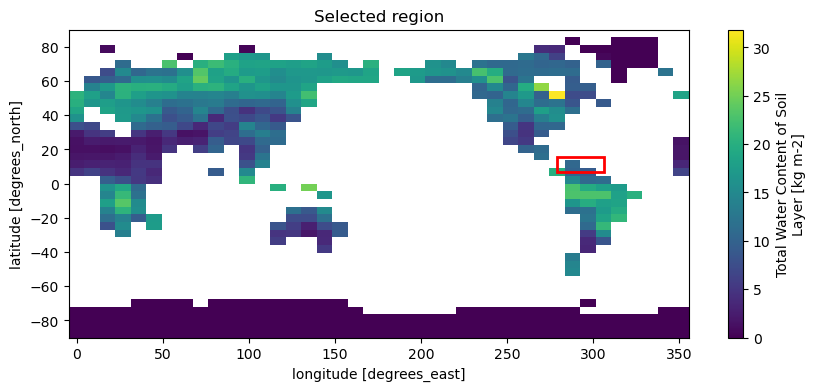

In [82]:
Play.plot_one_var.show_my_position(min_lat_idx=21,max_lat_idx=23, min_lon_idx=31,max_lon_idx=34)

In [83]:
min_lat_idx=21
max_lat_idx=23
min_lon_idx=31
max_lon_idx=34
mrsol_pruned_ds = mrsol_pruned_ds.isel(lat=slice(min_lat_idx,max_lat_idx), lon=slice(min_lon_idx,max_lon_idx))
input_ds = input_ds.isel(lat=slice(min_lat_idx,max_lat_idx), lon=slice(min_lon_idx,max_lon_idx))


In [84]:
mrsol_masked_ds, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds.drop_vars("depth_bnds"))
input_masked_ds = model.mask.mask_mask(input_ds,chunk_mask)


In [85]:
if multi_run:
    print((chunk_mask.isel(run=0).values != chunk_mask.isel(run=8).values).sum()) # the masks should be identical for all runs

0


In [86]:
mrsol_stack = mesmer.grid.stack_lat_lon(mrsol_masked_ds)

input_stack = mesmer.grid.stack_lat_lon(input_masked_ds)


### Quantiles

In [87]:
if multi_run:
    mrsol_stack = mrsol_stack.transpose("gridcell","depth","time","run")
    input_stack = input_stack.transpose("gridcell","time","run")
else:
    mrsol_stack = mrsol_stack.transpose("gridcell","depth","time")
    input_stack = input_stack.transpose("gridcell","time")


In [88]:

quantiles = np.linspace(0, 1, num_quantiles + 1)


In [89]:
if multi_run:
    bin_dim = ["time","run"]
else:
    bin_dim = "time"

if lin_bins:
    fractions = xr.DataArray(
        np.linspace(0, 1, num_quantiles + 1),
        dims=["quantile"],
    )

    tas_edges = (
        fractions
        * (
            input_stack["tas"].max(dim=bin_dim, skipna=True)
            - input_stack["tas"].min(dim=bin_dim, skipna=True)
        )
        +
        input_stack["tas"].min(dim=bin_dim, skipna=True)
    )

    pr_edges = (
        fractions
        * (
            input_stack["pr"].max(dim=bin_dim, skipna=True)
            - input_stack["pr"].min(dim=bin_dim, skipna=True)
        ) +
        input_stack["pr"].min(dim=bin_dim, skipna=True)
        
    )
else: 
    tas_edges = input_stack["tas"].quantile(
    quantiles,
    dim=bin_dim,
    skipna=True,
    )
    pr_edges = input_stack["pr"].quantile(
    quantiles,
    dim=bin_dim,
    skipna=True,
    )


In [90]:
""""
import xskillscore as xs

obs = xr.DataArray(np.array([0,1]), dims = ["events"],coords={"events": np.arange(0,2)})
fcst = xr.DataArray(np.array([[0,0],[1,2]]), dims = ["events","bin_member"],coords={"events": np.arange(0,2),"bin_member":np.arange(0,2)})
    

crps = xs.crps_ensemble(
    observations=obs,      # z.B. dim: ("member",)
    forecasts=fcst,        # z.B. dim: ("member", "ensemble")
    dim = [],
    member_dim="bin_member"
)

print(crps)
""";

In [91]:
def local_score(data,mask,old_scores,old_binsize):
    #print(gridcell)
    n_samples = mask.sum()
    new_binsize = old_binsize.copy()
    new_binsize[mask] = n_samples
    if n_samples == 0:
        return old_scores, new_binsize
    
    new_scores = old_scores.copy()

    #print(data[:,mask])
    for d in range(0,len(data)):
        targets = xr.DataArray(np.array(data[d,mask]), dims = ["events"],coords={"events": np.arange(0,n_samples)})
        #print(targets)
        bins = xr.DataArray(np.array([data[d,mask]]*n_samples), dims = ["events","bin_member"],coords={"events": np.arange(0,n_samples)})
        #print(bins)
        #print("done")

        #print(n_samples)
        #print(xs.crps_ensemble(targets,bins,member_dim="bin_member"))
        score = xs.crps_ensemble(targets,bins,dim=[],member_dim="bin_member")
        #print(score)
        #print(old_scores)
        #print(old_scores.shape)
        #print(mask.shape)
        #print("lul")
        new_scores[d,mask] = score.values
    return new_scores, new_binsize

In [92]:
"""
fig, axes = plt.subplots(
        num_quantiles,
        num_quantiles,
        figsize=(12, 12),
        sharex=True,
        sharey=True

    )
"""
#mrsol_bins = xr.full_like(mrsol_stack.expand_dims(bin_member=np.arange(mrsol_stack.sizes["time"])), np.nan)
mrsol_stack = mrsol_stack.isel(depth=slice(0,3))
crps_scores = xr.full_like(mrsol_stack,0).rename({"mrsol":"crps_score"})
tas_idx_mat = xr.full_like(mrsol_stack.mean("depth"),0).rename({"mrsol":"tas_idx"})
pr_idx_mat = xr.full_like(mrsol_stack.mean("depth"),0).rename({"mrsol":"pr_idx"})
bin_sizes = xr.full_like(mrsol_stack.mean("depth"),0).rename({"mrsol":"bin_size"})



for tas_idx in range(num_quantiles):
    for pr_idx in range(num_quantiles):
        mask = (
                (input_stack["tas"] >= tas_edges[tas_idx]) &
                (input_stack["tas"] < tas_edges[tas_idx+1]) &
                (input_stack["pr"] >= pr_edges[pr_idx]) &
                (input_stack["pr"] < pr_edges[pr_idx+1])
            )

        if multi_run:
            new_scores, new_binsize = xr.apply_ufunc(local_score,mrsol_stack["mrsol"].where(mask),mask,crps_scores["crps_score"],bin_sizes["bin_size"],input_core_dims=[["depth","time","run"], ["time","run"],["depth","time","run"],["time","run"]], output_core_dims=[["depth","time","run"],["time","run"]], vectorize = True)
        else :
            new_scores, new_binsize = xr.apply_ufunc(local_score,mrsol_stack["mrsol"].where(mask),mask,crps_scores["crps_score"],bin_sizes["bin_size"],input_core_dims=[["depth","time"], ["time"],["depth","time"],["time"]], output_core_dims=[["depth","time"],["time"]], vectorize = True)
                        
    
        crps_scores["crps_score"] = xr.where(mask,new_scores,crps_scores["crps_score"]) 

        bin_sizes["bin_size"] = xr.where(mask,new_binsize,bin_sizes["bin_size"])

        tas_idx_mat["tas_idx"] = xr.where(mask,tas_idx,tas_idx_mat["tas_idx"])
        
        pr_idx_mat["pr_idx"] = xr.where(mask,pr_idx,pr_idx_mat["pr_idx"])
        
    

        """
        for g in range(mrsol_stack.sizes["gridcell"]):
            for t in range(mrsol_stack.sizes["time"]):

                values = mrsol_stack["mrsol"][:, g].values[
                    mask[:, t, g]
                ]

                mrsol_bins["mrsol"][0:len(values), t, g] = values
        """
        #mrsol_bins = mrsol_stack.mrsol.where(mask)
        """
        bin_quantiles = xr_quantile_beta.mrsol.where(mask).values.flatten()
        bin_quantiles = bin_quantiles[np.isfinite(bin_quantiles)]
        axes[num_quantiles-tas_idx-1,pr_idx].hist(bin_quantiles.reshape(-1), bins = 100)
        """
        


#xr_quantile_beta
#quantile_beta
#bin_quantiles
#mrsol_stack.sizes["time"]
#mrsol_bins
#crps_scores.isel(depth=0).crps_score.plot()
bin_predictor = xr.merge([crps_scores,tas_idx_mat,pr_idx_mat,bin_sizes])

In [93]:
#bin_predictor

In [94]:
#pr_edges

In [95]:
bin_predictor_unstacked = mesmer.grid.unstack_lat_lon_and_align(bin_predictor,mrsol_pruned_ds.isel(depth=slice(0,3)))

In [96]:
#bin_predictor_unstacked

In [97]:
"""
max_bin = int(np.nanmax(bin_predictor_unstacked.bin_size.values))
print(max_bin)

depth = 0
if multi_run:
    avaraged_data = bin_predictor_unstacked.isel(depth=depth).mean("time").mean("run")
else:
    avaraged_data = bin_predictor_unstacked.isel(depth=depth).mean("time")


fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=max_bin+3,
    ncols=1,
    figsize=(8, max_bin * 4 + 12)
)
       
da = avaraged_data.crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = avaraged_data.bin_size
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("bin_size_mean")

for s in range(0,max_bin+1):
    da = xr.where((bin_predictor_unstacked.isel(depth=depth).bin_size == s), bin_predictor_unstacked.isel(depth=depth).crps_score, np.nan).mean("time")
    if multi_run:
        da = da.mean("run")
    da.plot(ax=ax[s+2])
    ax[s+2].coastlines()
    ax[s+2].set_title(f"crps_score for bin_size {s}")

"""

'\nmax_bin = int(np.nanmax(bin_predictor_unstacked.bin_size.values))\nprint(max_bin)\n\ndepth = 0\nif multi_run:\n    avaraged_data = bin_predictor_unstacked.isel(depth=depth).mean("time").mean("run")\nelse:\n    avaraged_data = bin_predictor_unstacked.isel(depth=depth).mean("time")\n\n\nfig_global_crpss, ax = plt.subplots(\n    subplot_kw={"projection": ccrs.PlateCarree()},\n    nrows=max_bin+3,\n    ncols=1,\n    figsize=(8, max_bin * 4 + 12)\n)\n\nda = avaraged_data.crps_score\nda.plot(ax=ax[0])\nax[0].coastlines()\nax[0].set_title("crps_score pred")\n\nda = avaraged_data.bin_size\nda.plot(ax=ax[1])\nax[1].coastlines()\nax[1].set_title("bin_size_mean")\n\nfor s in range(0,max_bin+1):\n    da = xr.where((bin_predictor_unstacked.isel(depth=depth).bin_size == s), bin_predictor_unstacked.isel(depth=depth).crps_score, np.nan).mean("time")\n    if multi_run:\n        da = da.mean("run")\n    da.plot(ax=ax[s+2])\n    ax[s+2].coastlines()\n    ax[s+2].set_title(f"crps_score for bin_size {s}

In [98]:
PIF = model.shape_data.load_plot(var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"fig_global_crpss_clipped_month_idx = {month_idx}_approx_mon_emp11")

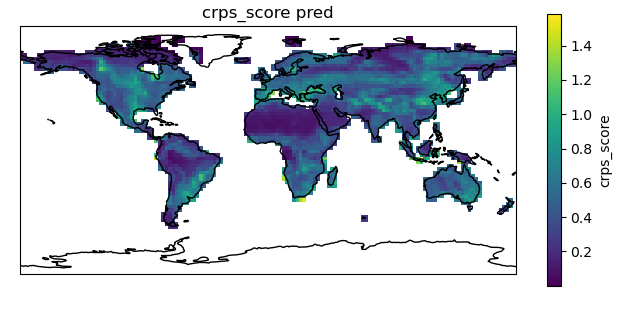

In [99]:
beta_PIF = PIF.crop((80, 130, 700, 440))
beta_PIF

In [100]:
"""
max_bin = int(np.nanmax(bin_predictor_unstacked.bin_size.values))
#print(max_bin)

depth = 0
if multi_run:
    avaraged_data = bin_predictor_unstacked.isel(depth=depth).mean("time").mean("run")
else:
    avaraged_data = bin_predictor_unstacked.isel(depth=depth).mean("time")

fig = plt.figure(figsize=(16, max_bin * 4 + 12))

ax = np.empty((max_bin+3, 2), dtype=object)

for p in range(max_bin+3):
    ax[p,0] = fig.add_subplot(max_bin+3, 2, 2*p+1,
                              projection=ccrs.PlateCarree())
    ax[p,1] = fig.add_subplot(max_bin+3, 2, 2*p+2)



da = avaraged_data.crps_score
da.plot(ax=ax[0,0])
ax[0,0].coastlines()
ax[0,0].set_title("crps_score pred")

da = avaraged_data.bin_size
da.plot(ax=ax[1,0])
ax[1,0].coastlines()
ax[1,0].set_title("bin_size_mean")

for s in range(0,max_bin+1):
    da = xr.where((bin_predictor_unstacked.isel(depth=depth).bin_size == s), bin_predictor_unstacked.isel(depth=depth).crps_score, np.nan).mean("time")
    if multi_run:
        da = da.mean("run")
    da.plot(ax=ax[s+2,0])
    ax[s+2,0].coastlines()
    ax[s+2,0].set_title(f"crps_score for bin_size {s}")

img = np.array(beta_PIF)
for p in range(0,max_bin+3):
    ax[p,1].clear()
    ax[p,1].imshow(img, aspect = "auto")
    #ax[p, 1].set_xlim(0, img.shape[1])
    #ax[p, 1].set_ylim(img.shape[0], 0)
    ax[p,1].axis("off")
    #print(p, ax[p,1].images)
"""

'\nmax_bin = int(np.nanmax(bin_predictor_unstacked.bin_size.values))\n#print(max_bin)\n\ndepth = 0\nif multi_run:\n    avaraged_data = bin_predictor_unstacked.isel(depth=depth).mean("time").mean("run")\nelse:\n    avaraged_data = bin_predictor_unstacked.isel(depth=depth).mean("time")\n\nfig = plt.figure(figsize=(16, max_bin * 4 + 12))\n\nax = np.empty((max_bin+3, 2), dtype=object)\n\nfor p in range(max_bin+3):\n    ax[p,0] = fig.add_subplot(max_bin+3, 2, 2*p+1,\n                              projection=ccrs.PlateCarree())\n    ax[p,1] = fig.add_subplot(max_bin+3, 2, 2*p+2)\n\n\n\nda = avaraged_data.crps_score\nda.plot(ax=ax[0,0])\nax[0,0].coastlines()\nax[0,0].set_title("crps_score pred")\n\nda = avaraged_data.bin_size\nda.plot(ax=ax[1,0])\nax[1,0].coastlines()\nax[1,0].set_title("bin_size_mean")\n\nfor s in range(0,max_bin+1):\n    da = xr.where((bin_predictor_unstacked.isel(depth=depth).bin_size == s), bin_predictor_unstacked.isel(depth=depth).crps_score, np.nan).mean("time")\n    if

In [101]:
#model.save.save_plot(fig, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"empirisches_limit_7x7_bin_size_crps_against_global_beta_approx_mon_emp11_crps_clipped_month_idx = {month_idx}")

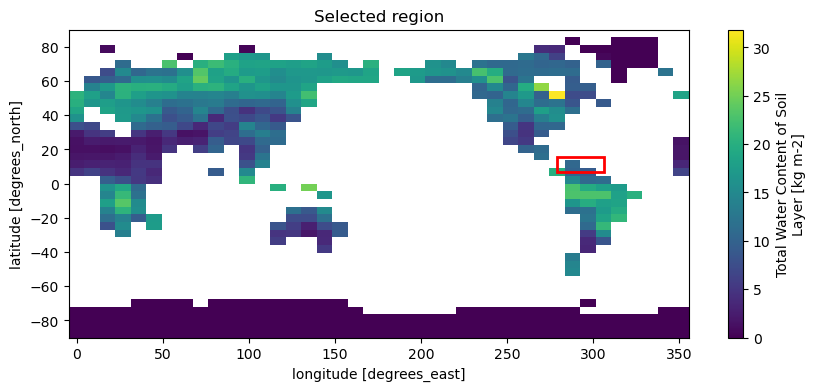

In [102]:
Play.plot_one_var.show_my_position(min_lat_idx=21,max_lat_idx=23, min_lon_idx=31,max_lon_idx=34)

In [103]:
lat = bin_predictor_unstacked.lat[0]
lon = bin_predictor_unstacked.lon[1]

In [104]:

local_bin_predictor = bin_predictor_unstacked.sel(lat= lat, lon =lon).isel(depth = 0)
local_mrsol = mrsol_masked_ds.sel(lat= lat, lon =lon).isel(depth = 0)
local_tas_edges = mesmer.grid.unstack_lat_lon(tas_edges).sel(lat= lat, lon =lon)
local_pr_edges = mesmer.grid.unstack_lat_lon(pr_edges).sel(lat= lat, lon =lon)

In [105]:
local_bin_predictor

<xarray.Dataset> Size: 149kB
Dimensions:     (time: 165, run: 28)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    height      float64 8B 2.0
    lon         float64 8B 288.0
    lat         float64 8B 6.75
    depth       float64 8B 0.03
Dimensions without coordinates: run
Data variables:
    crps_score  (time, run) float64 37kB 0.1261 0.1276 0.2212 ... 0.3268 0.1382
    tas_idx     (time, run) float64 37kB 5.0 17.0 11.0 12.0 ... 24.0 24.0 22.0
    pr_idx      (time, run) float64 37kB 19.0 15.0 15.0 14.0 ... 9.0 4.0 17.0
    bin_size    (time, run) float64 37kB 7.0 33.0 27.0 20.0 ... 18.0 3.0 5.0
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [106]:
local_mrsol

<xarray.Dataset> Size: 38kB
Dimensions:  (time: 165, run: 28)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-04-30 1851-04-30 ... 2014-04-30
    lon      float64 8B 288.0
    lat      float64 8B 6.75
    depth    float64 8B 0.03
    height   float64 8B 2.0
Dimensions without coordinates: run
Data variables:
    mrsol    (time, run) float64 37kB 14.19 12.04 13.42 ... 10.74 10.56 12.21
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [107]:
local_pr_edges

<xarray.DataArray (quantile: 41)> Size: 328B
array([8.88804069e-06, 1.20163106e-05, 1.51445804e-05, 1.82728503e-05,
       2.14011202e-05, 2.45293901e-05, 2.76576600e-05, 3.07859298e-05,
       3.39141997e-05, 3.70424696e-05, 4.01707395e-05, 4.32990093e-05,
       4.64272792e-05, 4.95555491e-05, 5.26838190e-05, 5.58120889e-05,
       5.89403587e-05, 6.20686286e-05, 6.51968985e-05, 6.83251684e-05,
       7.14534382e-05, 7.45817081e-05, 7.77099780e-05, 8.08382479e-05,
       8.39665178e-05, 8.70947876e-05, 9.02230575e-05, 9.33513274e-05,
       9.64795973e-05, 9.96078671e-05, 1.02736137e-04, 1.05864407e-04,
       1.08992677e-04, 1.12120947e-04, 1.15249217e-04, 1.18377486e-04,
       1.21505756e-04, 1.24634026e-04, 1.27762296e-04, 1.30890566e-04,
       1.34018836e-04])
Coordinates:
    lat      float64 8B 6.75
    lon      float64 8B 288.0
    height   float64 8B 2.0
Dimensions without coordinates: quantile
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          kg m-2 s-1
    comment:        includes both liquid and solid phases
    original_name:  pr
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [108]:
num_quantiles

40

In [109]:
fig_split, axes = plt.subplots(
        num_quantiles,
        num_quantiles,
        figsize=(4*num_quantiles, 4*num_quantiles),
        sharex=False,
        sharey=False

    )


for tas_idx in range(num_quantiles):
    for pr_idx in range(num_quantiles):
        mask = np.array((local_bin_predictor.tas_idx.values == tas_idx) & (local_bin_predictor.pr_idx.values == pr_idx))
        data = local_mrsol.mrsol.values[mask]
        
        score = np.mean(local_bin_predictor.crps_score.values[mask])

        axes[num_quantiles-tas_idx-1,pr_idx].hist(data,bins=20)
        axes[num_quantiles-tas_idx-1,pr_idx].set_ylim(0, axes[num_quantiles-tas_idx-1,pr_idx].get_ylim()[1] * 1.5)
        axes[num_quantiles-tas_idx-1,pr_idx].set_title(f"tas:{local_tas_edges[tas_idx]:.4g} to {local_tas_edges[tas_idx+1]:.4g},\n pr: {local_pr_edges[pr_idx]:.4g} to {local_pr_edges[pr_idx + 1]:.4g},\n score: {score:.4g},\n bin_size: {np.sum(mask)}", y = 0.66)



/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/pjunghans/miniconda3/envs/mesmer-tests/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [110]:
model.save.save_plot(fig_split,name="quicksave_giga_split")

In [111]:
#crps_scores["crps_score"].where(mask)#,crps_scores["gridcell"],mask

In [112]:
#(crps_scores.crps_score.max("time")-crps_scores.crps_score.min("time")).plot()